# 🔬 Breast Cancer Classification using K-Nearest Neighbors (KNN)
### Predictive Pattern Recognition & Diagnostics Pipeline

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load dataset natively
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target  # 0 = Malignant, 1 = Benign

print("Dataset Shape:", df.shape)
print("\n--- Class Distributions (0: Malignant, 1: Benign) ---")
print(df['target'].value_counts(normalize=True))
print("\n--- Missing Values Check ---")
print(f"Total Missing Records: {df.isnull().sum().sum()}")

Dataset Shape: (569, 31)

--- Class Distributions (0: Malignant, 1: Benign) ---
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

--- Missing Values Check ---
Total Missing Records: 0


/tmp/ipykernel_907/340336230.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(features_to_plot, rotation=15)


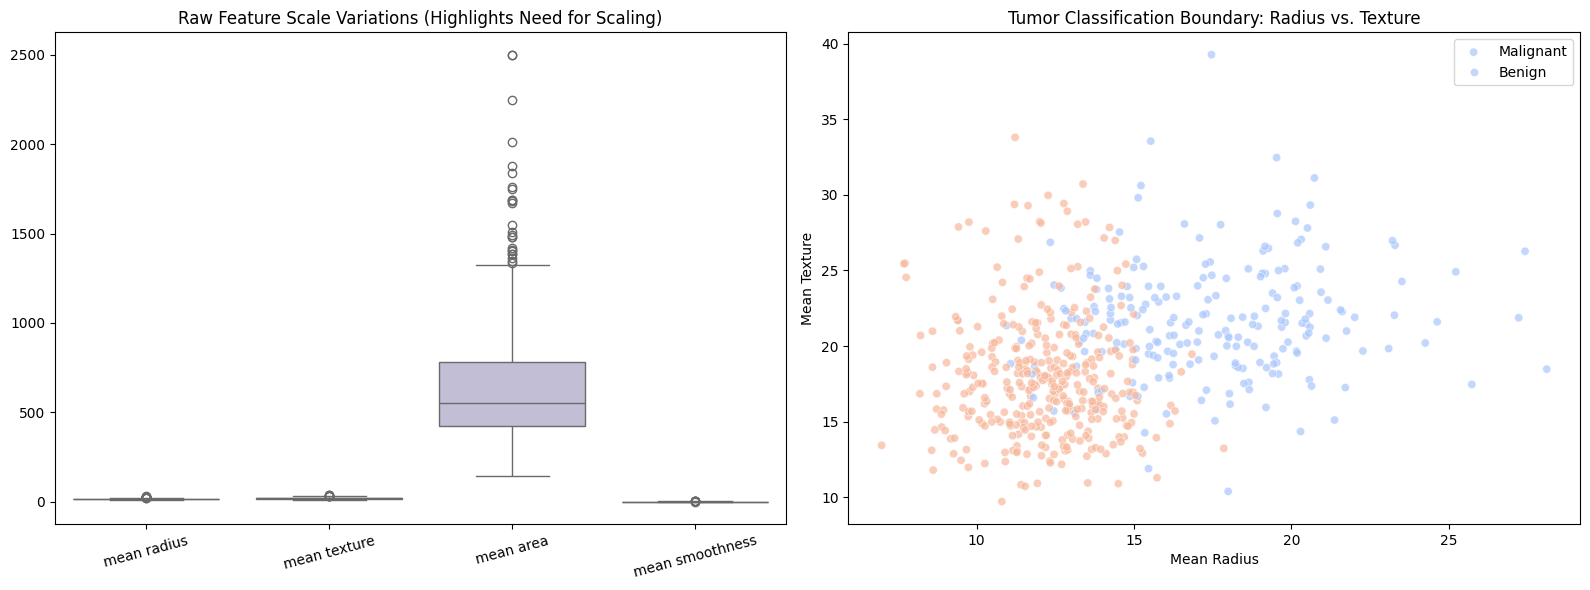

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot showcasing the massive discrepancy in feature scales before normalization
features_to_plot = ['mean radius', 'mean texture', 'mean area', 'mean smoothness']
sns.boxplot(data=df[features_to_plot], ax=axes[0], palette='Set3')
axes[0].set_title('Raw Feature Scale Variations (Highlights Need for Scaling)')
axes[0].set_xticklabels(features_to_plot, rotation=15)

# 2. Bivariate distribution of two major structural features split by target class
sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target', palette='coolwarm', alpha=0.7, ax=axes[1])
axes[1].set_title('Tumor Classification Boundary: Radius vs. Texture')
axes[1].set_xlabel('Mean Radius')
axes[1].set_ylabel('Mean Texture')
axes[1].legend(labels=['Malignant', 'Benign'])

plt.tight_layout()
plt.show()

In [10]:
X = df.drop(columns=['target'])
y = df['target']

# 80/20 train-test split with stratification to preserve class boundaries
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply StandardScaler (Crucial for distance-based calculations like KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Training Feature Matrix Shape:", X_train.shape)
print("Testing Feature Matrix Shape :", X_test.shape)

Training Feature Matrix Shape: (455, 30)
Testing Feature Matrix Shape : (114, 30)


In [11]:
# Test odd k values to prevent tie-breaking conflicts in classification voting
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    # 5-Fold Cross-Validation to identify stable accuracy performance
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Identify the optimal parameter configuration
optimal_k = k_values[np.argmax(cv_scores)]
print(f"Optimal Parameter Value identified via Cross-Validation: k = {optimal_k}")

Optimal Parameter Value identified via Cross-Validation: k = 3


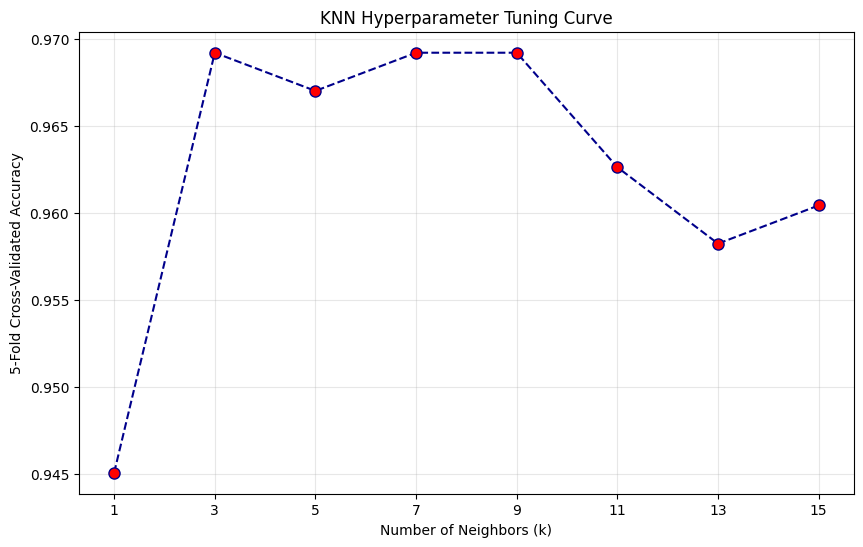

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='--', color='darkblue', markerfacecolor='red', markersize=8)
plt.title('KNN Hyperparameter Tuning Curve')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('5-Fold Cross-Validated Accuracy')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

--- Final Tuned KNN Model Performance Metrics ---
Accuracy Score : 0.9825
Precision Score: 0.9730
Recall Score   : 1.0000
Balanced F1    : 0.9863


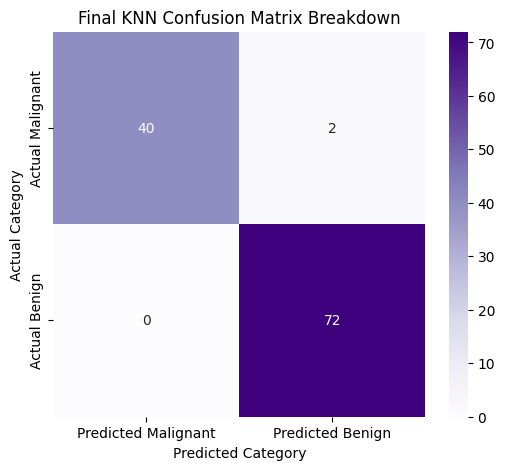

In [13]:
# Initialize and train final model with optimal tuned parameter
final_knn = KNeighborsClassifier(n_neighbors=optimal_k, metric='euclidean')
final_knn.fit(X_train, y_train)

# Generate predictions
y_pred = final_knn.predict(X_test)
y_prob = final_knn.predict_proba(X_test)[:, 1]

# Output evaluation parameters
print('--- Final Tuned KNN Model Performance Metrics ---')
print(f'Accuracy Score : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision Score: {precision_score(y_test, y_pred):.4f}')
print(f'Recall Score   : {recall_score(y_test, y_pred):.4f}')
print(f'Balanced F1    : {f1_score(y_test, y_pred):.4f}')

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Final KNN Confusion Matrix Breakdown')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

## ⚖️ Clinical and Operational Cost Trade-Offs

In diagnostic pattern recognition, classification errors contain deeply asymmetric risk stakes:

### 1. The Cost of a False Negative (Critical/Catastrophic Failure)
* **Scenario:** The model classifies a tumor as **Benign** (1), but it is actually **Malignant** (0).
* **Impact:** This is the most dangerous classification error. A patient with an active malignancy is sent home without treatment, allowing the disease to progress unmonitored. This leads directly to critical health outcomes and massive medical liability. Therefore, maximizing **Recall (Sensitivity)** is the primary optimization constraint for medical screening systems.

### 2. The Cost of a False Positive (Operational Sunk Cost)
* **Scenario:** The model classifies a tumor as **Malignant** (0), but it is actually **Benign** (1).
* **Impact:** While stressful for the patient, a False Positive results in an operational and financial buffer cost—requiring follow-up diagnostics, secondary screening, or bioptic validation. It represents a misallocation of clinical screening resources but does not present an immediate threat to patient survival.

In [14]:
# Generate two distinct sample points (Standardized using the historical training parameters)
sample_points = np.array([
    X_test_raw.iloc[0],  # Actual sample 1
    X_test_raw.iloc[-1]  # Actual sample 2
])

scaled_samples = scaler.transform(sample_points)
sample_predictions = final_knn.predict(scaled_samples)

print("--- Real-Time Production Inference Test ---")
for i, pred in enumerate(sample_predictions):
    label = "Benign" if pred == 1 else "Malignant"
    print(f"Synthetic Sample {i+1} Feature Array safely mapped. Predicted Diagnostic Profile: {label}")

--- Real-Time Production Inference Test ---
Synthetic Sample 1 Feature Array safely mapped. Predicted Diagnostic Profile: Malignant
Synthetic Sample 2 Feature Array safely mapped. Predicted Diagnostic Profile: Benign


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
